In [1]:
import hashlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

In [2]:
def encontrar_raiz_proyecto(inicio: Path) -> Path:
    inicio = inicio.resolve()

    for carpeta in [inicio, *inicio.parents]:
        if (carpeta / "regularizacion").exists():
            return carpeta

    raise FileNotFoundError(
        "No se encontró la carpeta regularizacion."
    )


PROJECT_ROOT = encontrar_raiz_proyecto(Path.cwd())
REG_DIR = PROJECT_ROOT / "regularizacion"

DATA_V1_DIR = REG_DIR / "data" / "v1"
DATA_V2_PROCESSED_DIR = REG_DIR / "data" / "v2" / "processed"
DATA_V3_DIR = REG_DIR / "data" / "v3"

OUTPUTS_V3_DIR = REG_DIR / "outputs" / "v3"
METRICS_V3_DIR = OUTPUTS_V3_DIR / "metrics"
FIGURES_V3_DIR = OUTPUTS_V3_DIR / "figures"
TENSORBOARD_V3_DIR = OUTPUTS_V3_DIR / "tensorboard"

MODELS_V3_DIR = REG_DIR / "models" / "v3"
CHECKPOINTS_V3_DIR = MODELS_V3_DIR / "checkpoints"
FINAL_V3_DIR = MODELS_V3_DIR / "final"
TFJS_V3_DIR = MODELS_V3_DIR / "tfjs"

for carpeta in [
    DATA_V3_DIR,
    METRICS_V3_DIR,
    FIGURES_V3_DIR,
    TENSORBOARD_V3_DIR,
    CHECKPOINTS_V3_DIR,
    FINAL_V3_DIR,
    TFJS_V3_DIR,
]:
    carpeta.mkdir(parents=True, exist_ok=True)

print("Dataset v1:", DATA_V1_DIR)
print("Dataset v2 procesado:", DATA_V2_PROCESSED_DIR)
print("Dataset combinado v3:", DATA_V3_DIR)

Dataset v1: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v1
Dataset v2 procesado: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v2\processed
Dataset combinado v3: C:\Users\Bastian\Desktop\Universidad\NOVENO SEMESTRE\IA\TALLER 3\regularizacion\data\v3


In [3]:
X_v1_raw = np.load(
    DATA_V1_DIR / "X.npy"
)

Y_v1_raw = np.load(
    DATA_V1_DIR / "Y.npy"
)

X_v2 = np.load(
    DATA_V2_PROCESSED_DIR / "X_clean.npy"
)

Y_v2 = np.load(
    DATA_V2_PROCESSED_DIR / "Y_clean.npy"
)

metadata_v2 = pd.read_csv(
    DATA_V2_PROCESSED_DIR / "metadata_clean.csv"
)

print("v1 X:", X_v1_raw.shape, X_v1_raw.dtype)
print("v1 Y:", Y_v1_raw.shape, Y_v1_raw.dtype)

print("v2 X:", X_v2.shape, X_v2.dtype)
print("v2 Y:", Y_v2.shape, Y_v2.dtype)

v1 X: (2062, 64, 64) float32
v1 Y: (2062, 10) float64
v2 X: (4598, 64, 64, 1) float32
v2 Y: (4598,) int32


In [17]:
# Posición activa dentro de cada etiqueta one-hot.
posiciones_originales_v1 = np.argmax(
    Y_v1_raw,
    axis=1
)

# Mapeo real de columna one-hot a dígito.
mapa_posicion_a_digito = np.array(
    [9, 0, 7, 6, 1, 8, 4, 3, 2, 5],
    dtype=np.int32
)

Y_v1 = mapa_posicion_a_digito[
    posiciones_originales_v1
]

print(
    "Clases corregidas de v1:",
    np.unique(Y_v1)
)

print(
    "Cantidad por dígito:",
    np.bincount(
        Y_v1,
        minlength=10
    )
)

Clases corregidas de v1: [0 1 2 3 4 5 6 7 8 9]
Cantidad por dígito: [205 206 206 206 207 207 207 206 208 204]


In [18]:
X_v1 = np.asarray(
    X_v1_raw,
    dtype=np.float32
)

# Solo divide si los datos aún están entre 0 y 255.
if X_v1.max() > 1.5:
    X_v1 = X_v1 / 255.0

X_v1 = np.clip(
    X_v1,
    0.0,
    1.0
)

if X_v1.ndim == 3:
    X_v1 = X_v1[..., np.newaxis]

print("Forma final v1:", X_v1.shape)
print("Tipo:", X_v1.dtype)
print(
    "Rango:",
    float(X_v1.min()),
    "a",
    float(X_v1.max())
)

Forma final v1: (2062, 64, 64, 1)
Tipo: float32
Rango: 0.003921568859368563 a 1.0


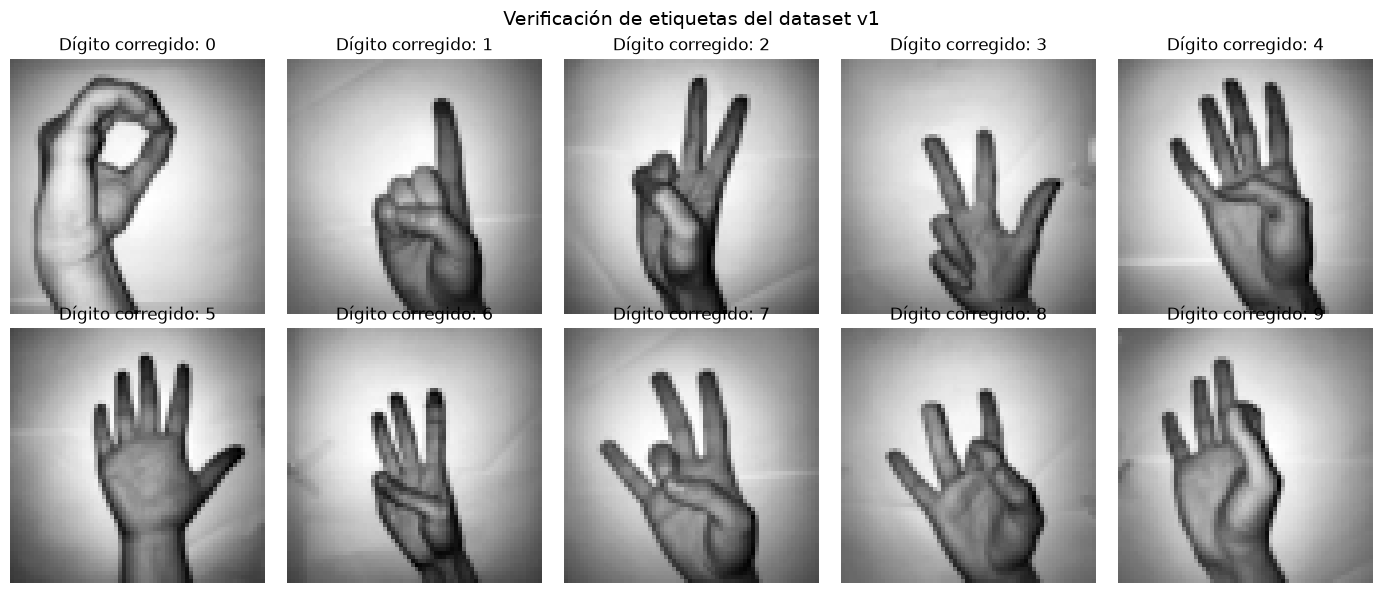

In [19]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 6)
)

axes = axes.flatten()

for digito in range(10):
    indices = np.where(Y_v1 == digito)[0]
    indice = indices[0]

    axes[digito].imshow(
        X_v1[indice].squeeze(),
        cmap="gray"
    )

    axes[digito].set_title(
        f"Dígito corregido: {digito}"
    )

    axes[digito].axis("off")

plt.suptitle(
    "Verificación de etiquetas del dataset v1",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    FIGURES_V3_DIR / "verificacion_etiquetas_v1.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

In [20]:
def imagen_a_uint8(imagen: np.ndarray) -> np.ndarray:
    imagen = np.asarray(
        imagen,
        dtype=np.float32
    ).squeeze()

    imagen = np.clip(
        imagen,
        0.0,
        1.0
    )

    return np.rint(
        imagen * 255.0
    ).astype(np.uint8)


def hash_imagen_normalizada(
    imagen: np.ndarray
) -> str:
    imagen_uint8 = np.ascontiguousarray(
        imagen_a_uint8(imagen)
    )

    return hashlib.blake2b(
        imagen_uint8.tobytes(),
        digest_size=16
    ).hexdigest()


hashes_v1 = [
    hash_imagen_normalizada(imagen)
    for imagen in X_v1
]

hashes_v2 = [
    hash_imagen_normalizada(imagen)
    for imagen in X_v2
]

print("Imágenes v1:", len(hashes_v1))
print("Imágenes únicas v1:", len(set(hashes_v1)))

print("Imágenes v2:", len(hashes_v2))
print("Imágenes únicas v2:", len(set(hashes_v2)))

coincidencias_entre_datasets = (
    set(hashes_v1)
    .intersection(set(hashes_v2))
)

print(
    "Coincidencias exactas entre v1 y v2:",
    len(coincidencias_entre_datasets)
)

Imágenes v1: 2062
Imágenes únicas v1: 2062
Imágenes v2: 4598
Imágenes únicas v2: 4598
Coincidencias exactas entre v1 y v2: 0


In [21]:
df_v1 = pd.DataFrame({
    "Indice_origen": np.arange(len(X_v1)),
    "Digito": Y_v1,
    "Origen": "v1",
    "Hash": hashes_v1,
})

df_v2 = pd.DataFrame({
    "Indice_origen": np.arange(len(X_v2)),
    "Digito": Y_v2.astype(np.int32),
    "Origen": "v2",
    "Hash": hashes_v2,
})

metadata_temporal = pd.concat(
    [df_v1, df_v2],
    ignore_index=True
)

resumen_hash = (
    metadata_temporal
    .groupby("Hash")
    .agg(
        Cantidad=("Hash", "size"),
        Cantidad_origenes=(
            "Origen",
            lambda valores: len(set(valores))
        ),
        Digitos=(
            "Digito",
            lambda valores: tuple(
                sorted(set(valores))
            )
        ),
    )
    .reset_index()
)

resumen_hash["Cantidad_digitos"] = (
    resumen_hash["Digitos"].apply(len)
)

conflictos = resumen_hash[
    resumen_hash["Cantidad_digitos"] > 1
]

print(
    "Imágenes idénticas con etiquetas diferentes:",
    len(conflictos)
)

if len(conflictos) > 0:
    display(conflictos.head(20))
else:
    print(
        "No existen conflictos de etiquetas."
    )

Imágenes idénticas con etiquetas diferentes: 0
No existen conflictos de etiquetas.


In [22]:
X_temporal = np.concatenate(
    [X_v1, X_v2],
    axis=0
).astype(np.float32)

Y_temporal = np.concatenate(
    [
        Y_v1,
        Y_v2.astype(np.int32)
    ],
    axis=0
)

origen_temporal = np.concatenate(
    [
        np.full(len(X_v1), "v1"),
        np.full(len(X_v2), "v2")
    ]
)

indice_origen_temporal = np.concatenate(
    [
        np.arange(len(X_v1)),
        np.arange(len(X_v2))
    ]
)

hashes_temporales = np.array(
    hashes_v1 + hashes_v2
)

metadata_combined = pd.DataFrame({
    "Indice_temporal": np.arange(
        len(X_temporal)
    ),
    "Indice_origen": indice_origen_temporal,
    "Digito": Y_temporal,
    "Origen": origen_temporal,
    "Hash": hashes_temporales,
})

indices_unicos = (
    metadata_combined
    .drop_duplicates(
        subset="Hash",
        keep="first"
    )["Indice_temporal"]
    .to_numpy()
)

X_combined = X_temporal[
    indices_unicos
]

Y_combined = Y_temporal[
    indices_unicos
].astype(np.int32)

metadata_combined = (
    metadata_combined
    .iloc[indices_unicos]
    .reset_index(drop=True)
)

metadata_combined.insert(
    0,
    "Indice_combinado",
    np.arange(len(metadata_combined))
)

print("Cantidad antes de eliminar duplicados:", len(X_temporal))
print("Cantidad final combinada:", len(X_combined))
print(
    "Duplicados eliminados al combinar:",
    len(X_temporal) - len(X_combined)
)

Cantidad antes de eliminar duplicados: 6660
Cantidad final combinada: 6660
Duplicados eliminados al combinar: 0


In [23]:
tabla_distribucion_combinada = (
    metadata_combined
    .groupby(
        ["Digito", "Origen"]
    )
    .size()
    .unstack(
        fill_value=0
    )
    .reset_index()
)

tabla_distribucion_combinada["Total"] = (
    tabla_distribucion_combinada
    .drop(columns="Digito")
    .sum(axis=1)
)

tabla_distribucion_combinada

Origen,Digito,v1,v2,Total
0,0,205,420,625
1,1,206,499,705
2,2,206,499,705
3,3,206,420,626
4,4,207,484,691
5,5,207,500,707
6,6,207,449,656
7,7,206,418,624
8,8,208,410,618
9,9,204,499,703


In [24]:
print(
    metadata_combined["Origen"]
    .value_counts()
)

print()

print(
    metadata_combined["Digito"]
    .value_counts()
    .sort_index()
)

Origen
v2    4598
v1    2062
Name: count, dtype: int64

Digito
0    625
1    705
2    705
3    626
4    691
5    707
6    656
7    624
8    618
9    703
Name: count, dtype: int64


In [25]:
estratos = (
    metadata_combined["Origen"]
    + "_digito_"
    + metadata_combined["Digito"].astype(str)
)

print(
    "Cantidad de estratos:",
    estratos.nunique()
)

print(
    estratos.value_counts().sort_index()
)

Cantidad de estratos: 20
v1_digito_0    205
v1_digito_1    206
v1_digito_2    206
v1_digito_3    206
v1_digito_4    207
v1_digito_5    207
v1_digito_6    207
v1_digito_7    206
v1_digito_8    208
v1_digito_9    204
v2_digito_0    420
v2_digito_1    499
v2_digito_2    499
v2_digito_3    420
v2_digito_4    484
v2_digito_5    500
v2_digito_6    449
v2_digito_7    418
v2_digito_8    410
v2_digito_9    499
Name: count, dtype: int64


In [26]:
SEED = 42

indices_totales = np.arange(
    len(Y_combined)
)

indices_train, indices_temporales = train_test_split(
    indices_totales,
    test_size=0.20,
    random_state=SEED,
    stratify=estratos
)

estratos_temporales = estratos.iloc[
    indices_temporales
]

indices_val, indices_test = train_test_split(
    indices_temporales,
    test_size=0.50,
    random_state=SEED,
    stratify=estratos_temporales
)

print("Total:", len(indices_totales))
print("Entrenamiento:", len(indices_train))
print("Validación:", len(indices_val))
print("Prueba:", len(indices_test))

Total: 6660
Entrenamiento: 5328
Validación: 666
Prueba: 666


In [27]:
def resumen_split(
    nombre: str,
    indices: np.ndarray
) -> pd.DataFrame:
    resumen = (
        metadata_combined
        .iloc[indices]
        .groupby(
            ["Digito", "Origen"]
        )
        .size()
        .unstack(
            fill_value=0
        )
        .reset_index()
    )

    resumen.insert(
        0,
        "Conjunto",
        nombre
    )

    return resumen


tabla_splits = pd.concat(
    [
        resumen_split(
            "Entrenamiento",
            indices_train
        ),
        resumen_split(
            "Validacion",
            indices_val
        ),
        resumen_split(
            "Prueba",
            indices_test
        ),
    ],
    ignore_index=True
)

tabla_splits

Origen,Conjunto,Digito,v1,v2
0,Entrenamiento,0,164,336
1,Entrenamiento,1,165,399
2,Entrenamiento,2,165,399
3,Entrenamiento,3,165,336
4,Entrenamiento,4,166,387
5,Entrenamiento,5,166,400
6,Entrenamiento,6,166,359
7,Entrenamiento,7,165,334
8,Entrenamiento,8,166,328
9,Entrenamiento,9,163,399


In [28]:
hashes_finales = metadata_combined[
    "Hash"
].to_numpy()

hashes_train = set(
    hashes_finales[indices_train]
)

hashes_val = set(
    hashes_finales[indices_val]
)

hashes_test = set(
    hashes_finales[indices_test]
)

print(
    "Coincidencias train-validación:",
    len(hashes_train & hashes_val)
)

print(
    "Coincidencias train-prueba:",
    len(hashes_train & hashes_test)
)

print(
    "Coincidencias validación-prueba:",
    len(hashes_val & hashes_test)
)

Coincidencias train-validación: 0
Coincidencias train-prueba: 0
Coincidencias validación-prueba: 0


In [29]:
np.save(
    DATA_V3_DIR / "X_combined.npy",
    X_combined.astype(np.float32)
)

np.save(
    DATA_V3_DIR / "Y_combined.npy",
    Y_combined.astype(np.int32)
)

metadata_combined.to_csv(
    DATA_V3_DIR / "metadata_combined.csv",
    index=False
)

np.savez(
    DATA_V3_DIR / "split_indices.npz",
    train=indices_train,
    validation=indices_val,
    test=indices_test,
    seed=np.array([SEED])
)

tabla_distribucion_combinada.to_csv(
    METRICS_V3_DIR
    / "distribucion_dataset_combinado.csv",
    index=False
)

tabla_splits.to_csv(
    METRICS_V3_DIR
    / "distribucion_splits_origen_digito.csv",
    index=False
)

print("Dataset v3 guardado correctamente.")
print("Forma de X:", X_combined.shape)
print("Forma de Y:", Y_combined.shape)

Dataset v3 guardado correctamente.
Forma de X: (6660, 64, 64, 1)
Forma de Y: (6660,)


## Resultado de la integración de los datasets

El dataset combinado v3 fue construido utilizando 2.062 imágenes del
dataset v1 y 4.598 imágenes únicas del dataset v2, alcanzando un total
de 6.660 muestras.

Las etiquetas del dataset v1 fueron corregidas mediante un mapeo
verificado visualmente. Ambos datasets fueron normalizados al intervalo
entre 0 y 1 y adaptados a la forma 64 × 64 × 1.

No se encontraron imágenes idénticas entre ambos datasets ni conflictos
en sus etiquetas. Posteriormente, las muestras fueron divididas de
manera estratificada considerando simultáneamente el dígito y el dataset
de origen.

La división final quedó compuesta por 5.328 imágenes de entrenamiento,
666 de validación y 666 de prueba. Se comprobó que no existen duplicados
exactos compartidos entre estos conjuntos.

In [30]:
print("Forma de Y_v2:", Y_v2.shape)
print("Tipo:", Y_v2.dtype)
print("Clases presentes:", np.unique(Y_v2))
print("Cantidad por clase:", np.bincount(Y_v2, minlength=10))

assert Y_v2.ndim == 1
assert np.array_equal(
    np.unique(Y_v2),
    np.arange(10)
)

print("La estructura numérica de las etiquetas es correcta.")

Forma de Y_v2: (4598,)
Tipo: int32
Clases presentes: [0 1 2 3 4 5 6 7 8 9]
Cantidad por clase: [420 499 499 420 484 500 449 418 410 499]
La estructura numérica de las etiquetas es correcta.


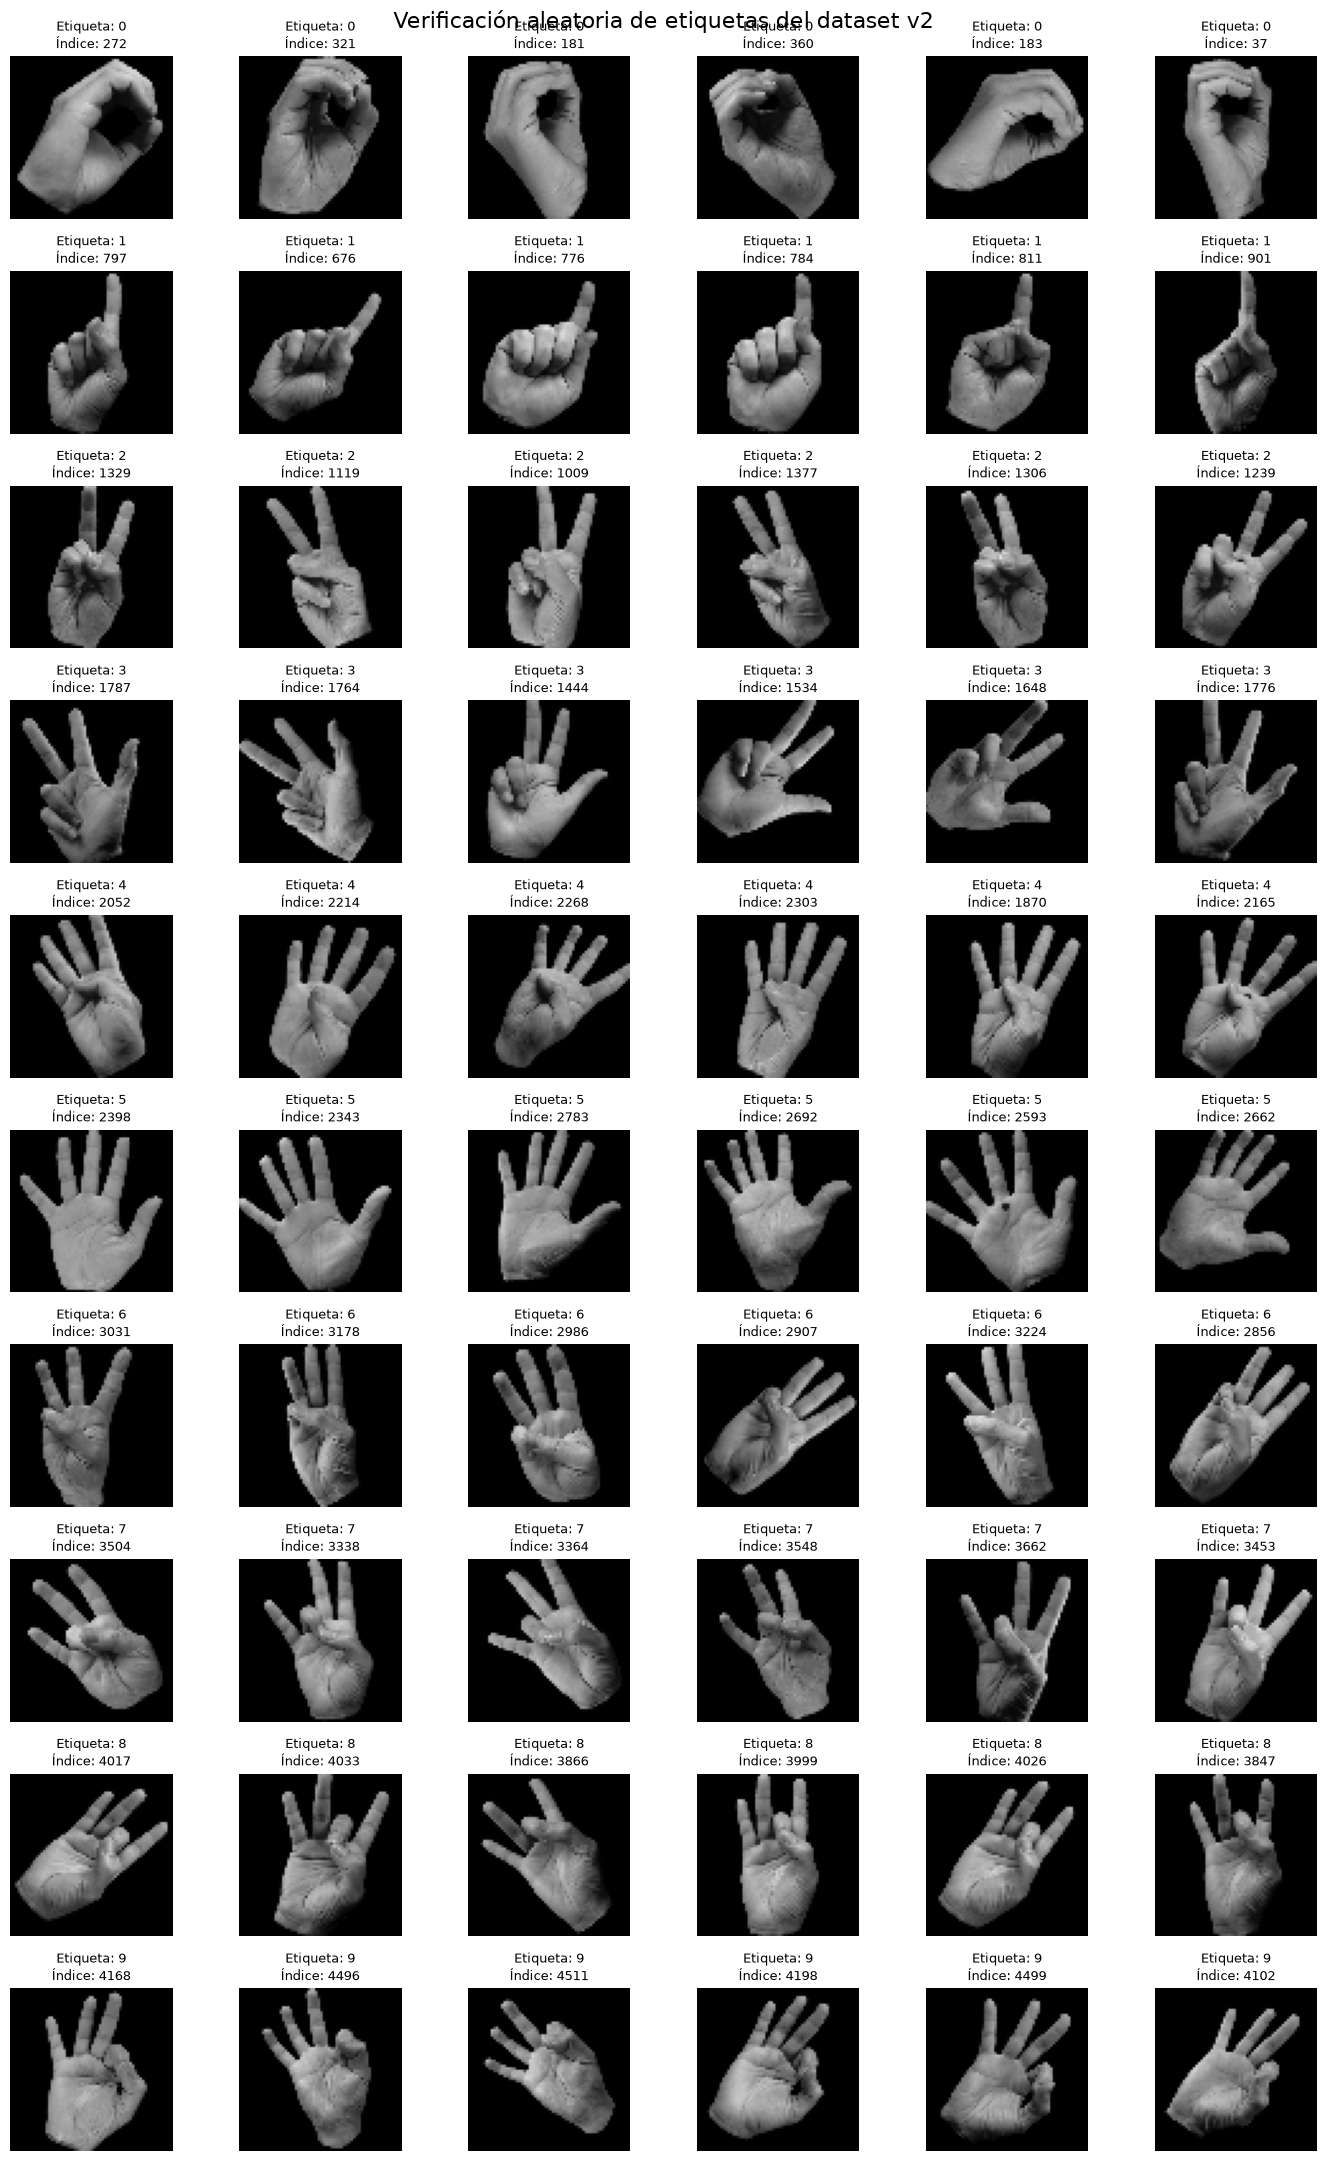

In [31]:
SEMILLA_VISUAL = 42
MUESTRAS_POR_CLASE = 6

generador_aleatorio = np.random.default_rng(
    SEMILLA_VISUAL
)

fig, axes = plt.subplots(
    10,
    MUESTRAS_POR_CLASE,
    figsize=(14, 22)
)

for digito in range(10):
    indices_clase = np.where(
        Y_v2 == digito
    )[0]

    indices_elegidos = generador_aleatorio.choice(
        indices_clase,
        size=MUESTRAS_POR_CLASE,
        replace=False
    )

    for columna, indice in enumerate(
        indices_elegidos
    ):
        axes[digito, columna].imshow(
            X_v2[indice].squeeze(),
            cmap="gray",
            vmin=0.0,
            vmax=1.0
        )

        axes[digito, columna].set_title(
            f"Etiqueta: {digito}\n"
            f"Índice: {indice}",
            fontsize=9
        )

        axes[digito, columna].axis("off")

plt.suptitle(
    "Verificación aleatoria de etiquetas del dataset v2",
    fontsize=16
)

plt.tight_layout()

plt.savefig(
    FIGURES_V3_DIR
    / "verificacion_etiquetas_v2.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()

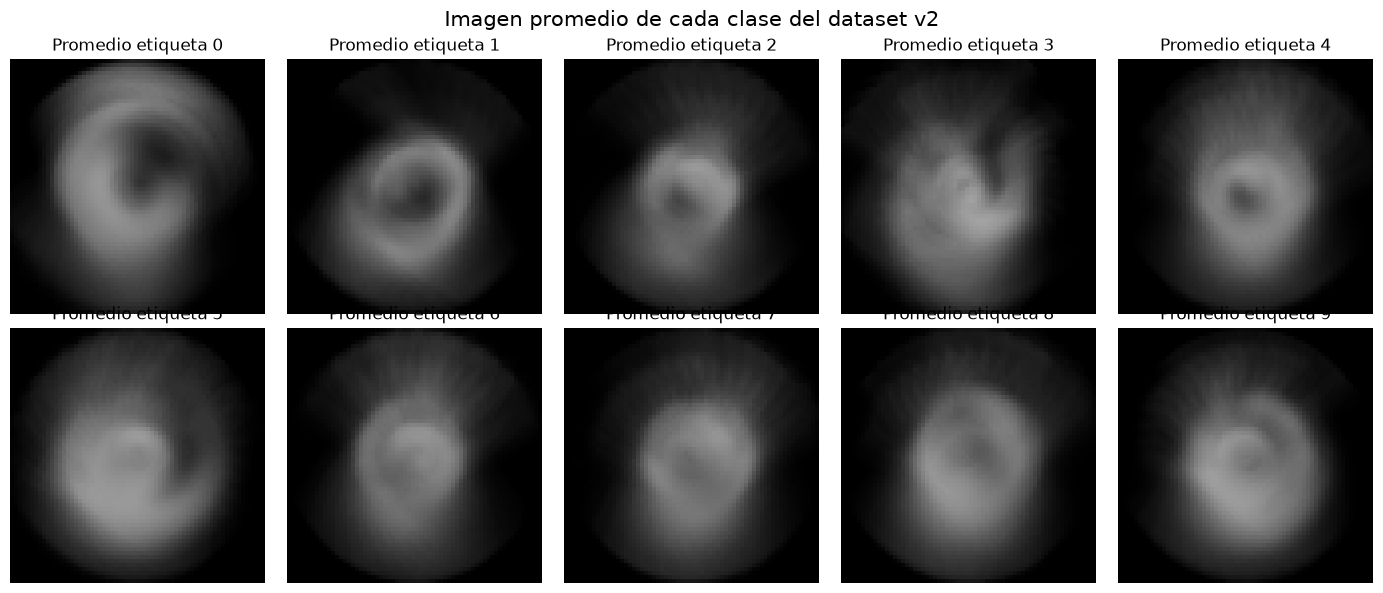

In [32]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(14, 6)
)

axes = axes.flatten()

for digito in range(10):
    imagen_promedio = X_v2[
        Y_v2 == digito
    ].mean(axis=0).squeeze()

    axes[digito].imshow(
        imagen_promedio,
        cmap="gray",
        vmin=0.0,
        vmax=1.0
    )

    axes[digito].set_title(
        f"Promedio etiqueta {digito}"
    )

    axes[digito].axis("off")

plt.suptitle(
    "Imagen promedio de cada clase del dataset v2",
    fontsize=15
)

plt.tight_layout()
plt.show()